#Project Description:
This project focuses on analyzing e-commerce transactional data to understand customer purchasing behavior. Using machine learning techniques, customers are segmented based on recency, frequency, and monetary value, and a predictive model is built to identify high-value and repeat customers. The insights from this analysis help improve targeted marketing strategies, enhance customer retention, and support data-driven inventory optimization.

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


In [2]:
# load dataset
df = pd.read_csv("/content/data.csv", encoding="ISO-8859-1", low_memory=False)


In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
# Create Clean Working Copy
df_clean = df.copy()

In [9]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [10]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [11]:
# checking cancelled transcation using invoice no starting with C
df[df['InvoiceNo'].str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [12]:
df['InvoiceNo'].str.startswith('C').sum()

np.int64(9288)

In [13]:
# removing cancelled transaction
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]

In [14]:
df_clean['InvoiceNo'].str.startswith('C').sum()

np.int64(0)

In [15]:
# checking quantity and unit price less than 0 which should be removed
(df_clean['Quantity'] <= 0).sum(), (df['UnitPrice'] <= 0).sum()

(np.int64(0), np.int64(2517))

In [16]:
# excluding quantity and unit price less than 0 and
# including which are greater than 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [17]:
(df_clean['Quantity'] <= 0).sum(), (df_clean['UnitPrice'] <= 0).sum()

(np.int64(0), np.int64(0))

In [18]:
# Convert Date (CRITICAL for RFM)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [19]:
# Create TotalAmount
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']


In [20]:
# verification
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [21]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [22]:
# Combine all transactions of a customer. One row per customer.
# We are aggregating transactions into customer-level summary.
df_clean['CustomerID'].nunique()

4338

calculate Recency, which represents the number of days since a customer’s most recent purchase.We use the last transaction date in the dataset as a reference date (acting as “today”) and compute the difference between this reference date and each customer’s last purchase date.

In [23]:
# Define reference date (acts as 'today' for recency calculation)
reference_date = df_clean['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [24]:
# Calculate Recency
# Recency = number of days since the customer's last purchase
recency_df = df_clean.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days
recency_df.head()


,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


Frequency means how many transactions (invoices) each customer has made
We count InvoiceNo per CustomerID

In [25]:
# calculate frequency
frequency_df = df_clean.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


Monetary represents the total amount of money spent by each customer,
We first calculate TotalAmount = Quantity * UnitPrice,
Then we sum TotalAmount for each CustomerID

In [26]:
monetary_df = df_clean.groupby('CustomerID')['TotalAmount'].sum().reset_index()
monetary_df.rename(columns={'TotalAmount': 'Monetary'}, inplace=True)
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [27]:
monetary_df.shape

(4338, 2)

In [28]:
rf_df = pd.merge(recency_df, frequency_df, on='CustomerID', how='inner')

In [29]:
rfm_df = pd.merge(rf_df, monetary_df, on='CustomerID', how='inner')


In [30]:
# Keep only RFM features + CustomerID
rfm_df = rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

In [31]:
# rfm table which displays insights about customer behaviour
# receny    - number of days since customers last purchase
# frequency - how frequent transaction done by customer
# monetary  - total amount spend by each customer
rfm_df


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40
...,...,...,...,...
4333,18280.0,277,1,180.60
4334,18281.0,180,1,80.82
4335,18282.0,7,2,178.05
4336,18283.0,3,16,2094.88


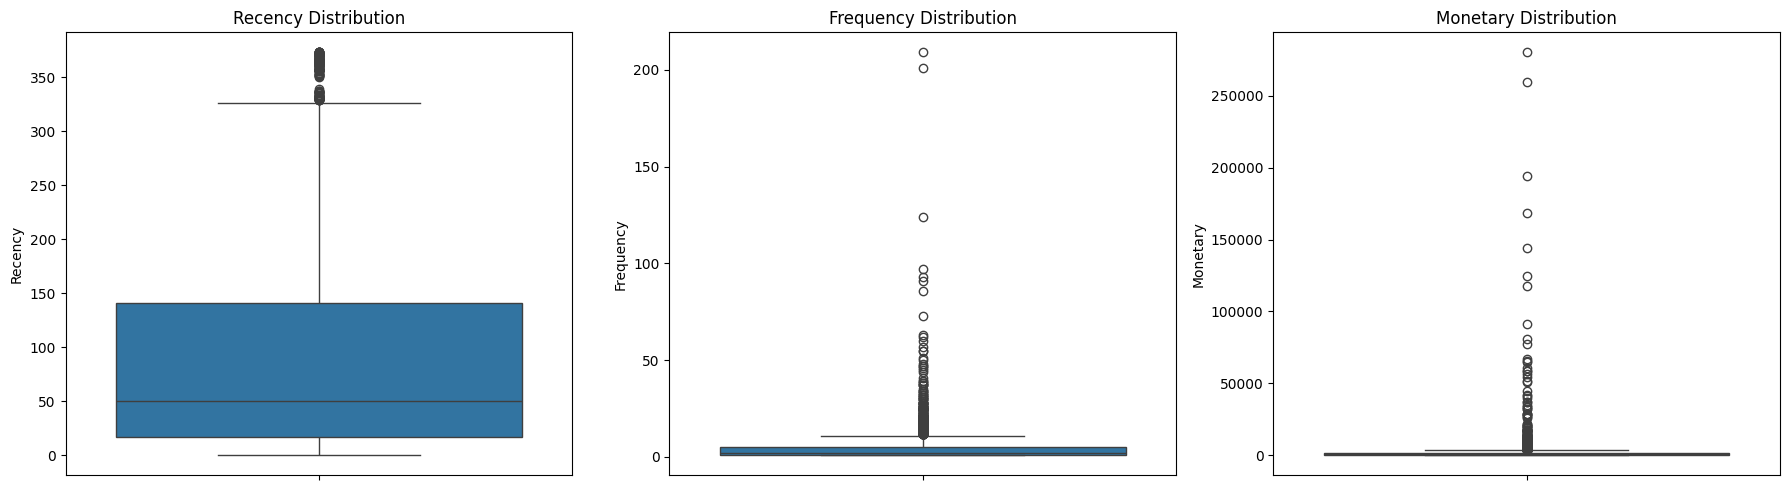

In [32]:
# Outlier visualization using boxplots

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_df['Recency'])
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_df['Frequency'])
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_df['Monetary'])
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [33]:
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

In [34]:
# Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [35]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

In [36]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02
max,2.814561e+00,2.659803e+01,3.094634e+01


In [37]:
# Try different cluster counts (k = 1 to 10)
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)



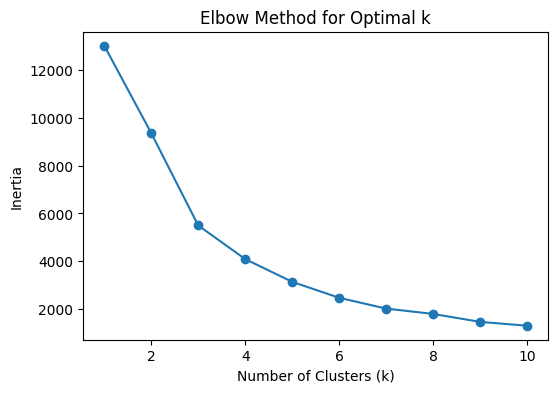

In [38]:
# Plot the Elbow curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [39]:
# Apply KMeans clustering with k = 4 using elbow method
# Fit the model and assign cluster labels
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

In [40]:
rfm_df['Cluster'].value_counts()

,count
Cluster,
0,3054
1,1067
3,204
2,13


In [41]:
# Calculate average RFM values for each cluster to understand typical customer behavior per segment
#| Cluster   | Customer Type                  | Reason                                                 |
#| --------- | ------------------------------ | ------------------------------------------------------ |
#| Cluster 0 | **Regular Customers**          | Moderate recency, moderate frequency, moderate spend   |
#| Cluster 1 | **Lost / Low-value Customers** | High recency (long time ago), low frequency, low spend |
#| Cluster 2 | **VIP / High-Value Customers** | Very high frequency & monetary                         |
#| Cluster 3 | **Potential Loyal Customers**  | Recent purchases, decent frequency & spend             |
rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()


,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1359.049284
1,247.075914,1.552015,480.617480
2,6.384615,82.538462,127338.313846
3,14.500000,22.333333,12709.090490


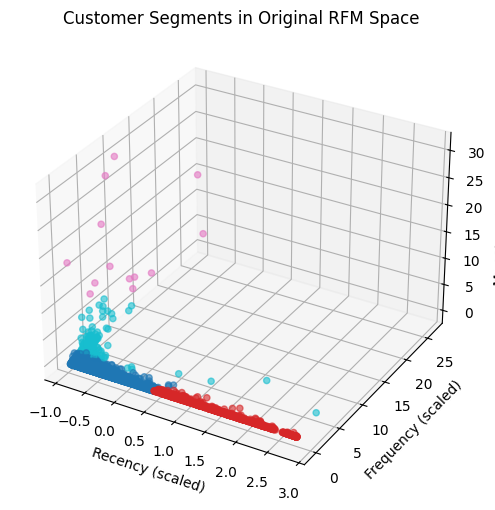

In [42]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_scaled_df['Recency'],
    rfm_scaled_df['Frequency'],
    rfm_scaled_df['Monetary'],
    c=rfm_df['Cluster'],
    cmap='tab10',
    alpha=0.6
)

ax.set_xlabel('Recency (scaled)')
ax.set_ylabel('Frequency (scaled)')
ax.set_zlabel('Monetary (scaled)')
ax.set_title('Customer Segments in Original RFM Space')

plt.show()

# PCA

In [43]:
# Initialize PCA to reduce 3 RFM features into 2 components for visualization
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled_df)
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)
pca_df['Cluster'] = rfm_df['Cluster']

In [44]:
# PC1 → combination of Recency, Frequency, Monetary
# PC2 → another combination of Recency, Frequency, Monetary
# Cluster → label assigned by KMeans
# So each point = one customer, positioned in 2D space, colored by cluster.
# This allows us to VISUALLY validate whether clustering makes sense.
pca_df.head()

,PC1,PC2,Cluster
0,4.106623,5.433579,3
1,0.742411,-0.671300,0
2,0.024802,-0.174954,0
3,-0.028036,-0.735124,0
4,-1.235466,1.834946,1


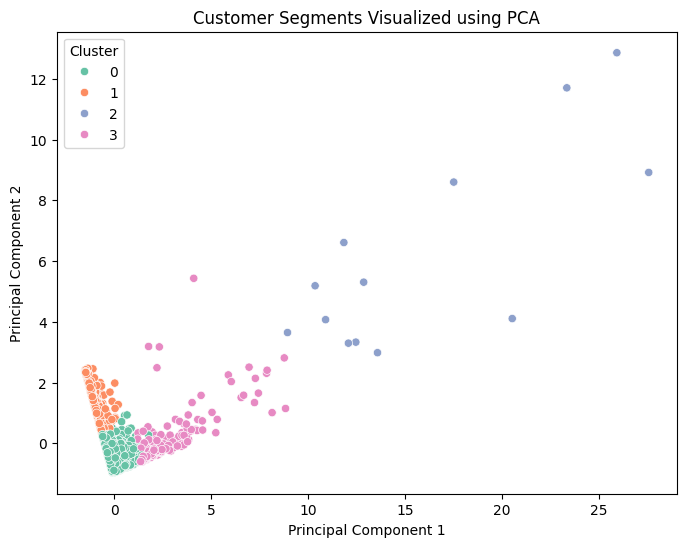

In [45]:
# Visualize KMeans customer clusters in 2D using PCA
# Cluster interpretation based on RFM averages:
# Cluster 0: Regular customers
# Cluster 1: Low-value / inactive customers
# Cluster 2: High-value (VIP) customers
# Cluster 3: Potential loyal customers
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [46]:
# Silhouette Score - Measures how well each customer fits in its cluster
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(rfm_scaled_df, rfm_df['Cluster'])
sil_score

np.float64(0.616212846765192)

In [47]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

rfm_df['Hierarchical_Cluster'] = hierarchical.fit_predict(rfm_scaled_df)

In [48]:
from sklearn.metrics import silhouette_score

hier_sil_score = silhouette_score(
    rfm_scaled_df,
    rfm_df['Hierarchical_Cluster']
)

hier_sil_score

np.float64(0.6073447738271717)

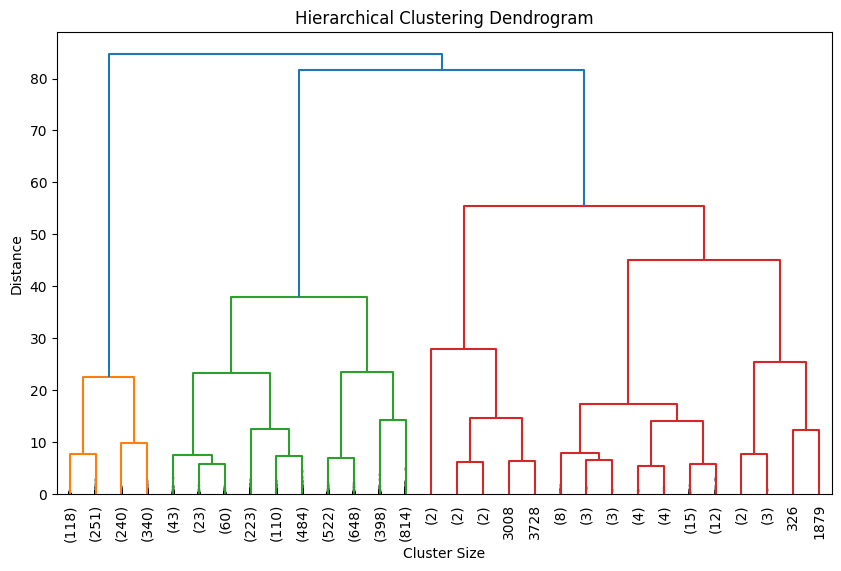

In [49]:
# Create linkage matrix
linked = linkage(rfm_scaled_df, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

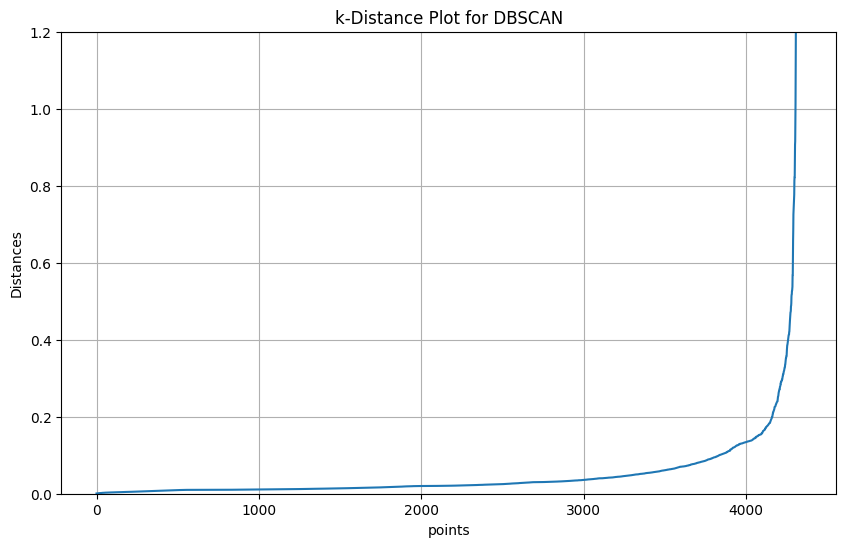

In [50]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(rfm_scaled_df)
distances,indices = neigh.kneighbors(rfm_scaled_df)

k_distances = np.sort(distances[:,3],axis = 0)

plt.figure(figsize=(10,6))
plt.plot(k_distances)
plt.ylim(0, 1.2)
plt.xlabel('points')
plt.ylabel('Distances')
plt.title("k-Distance Plot for DBSCAN")
plt.grid(True)
plt.show()

In [51]:
# Apply DBSCAN on scaled RFM data
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled_df)

# Add DBSCAN labels to dataframe
rfm_df['DBSCAN_Cluster'] = dbscan_labels

# Check cluster distribution
rfm_df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,4225
-1,107
1,6


In [52]:
X = rfm_scaled_df
labels = dbscan_labels

# Step 1: remove noise
mask = labels != -1
X_clustered = X[mask]
labels_clustered = labels[mask]

# Step 2: check cluster count
n_clusters = len(set(labels_clustered))

if n_clusters > 1:
    score = silhouette_score(X_clustered, labels_clustered)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be computed (only one cluster)")

Silhouette Score: 0.6742933147141902


In [53]:
dbscan_cluster_summary = rfm_df.groupby('DBSCAN_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print('Average RFM values for each DBSCAN Cluster:')
print(dbscan_cluster_summary)

Average RFM values for each DBSCAN Cluster:
                  Recency  Frequency      Monetary
DBSCAN_Cluster                                    
-1              47.411215  30.102804  32218.073551
 0              92.779408   3.581775   1266.494986
 1               3.166667  29.666667  18855.453333


Silhouette Score: 0.5721247262009418 for epsilon value 0.2

Silhouette Score: 0.6742933147141902 for epsilon value 0.3

Based on the k-distance elbow method, ε values between 0.2 and 0.3 were evaluated.

DBSCAN with ε = 0.3 and min_samples = 5 produced:

Fewer noise points

More stable clusters

Higher Silhouette Score (0.674)

Therefore, ε = 0.3 is selected as the optimal epsilon for DBSCAN

*   **Labels:**
    *   **-1 (Noise):** These are data points that don't belong to any cluster. They are considered outliers or anomalies.
    *   **0, 1 (Clusters):** These are the identified dense clusters. Each number represents a distinct group of customers with similar RFM characteristics.

### Interpretation of the Clusters:

Based on the average RFM values, we can interpret the clusters:

*   **Cluster 0:** This is the largest cluster. Examining its average Recency, Frequency, and Monetary values (from the table above), we can likely characterize these as **'Regular/Mid-Value Customers'**. They have moderate recency (not too recent, not too old), moderate frequency of purchases, and a moderate spending amount.

*   **Cluster 1:** This is a smaller cluster with very high average Recency, Frequency, and Monetary values. These are likely **'High-Value / Frequent Spenders'**. They are characterized by extremely low recency (very recent purchases), very high frequency, and very high monetary value. These are your most valuable customers.

*   **Cluster -1 (Noise):** These are individual customers whose RFM behaviors are quite different from the main dense clusters. They could be one-off huge spenders, very infrequent buyers, or customers with unusual purchasing patterns that don't fit neatly into the typical segments.

# prediction phase

In [54]:
# Features (Scaled RFM values)
X = rfm_scaled_df

# Target (Cluster assigned by KMeans with k=4)
y = rfm_df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
y_pred = rf_model.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9965437788018433


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       596
           1       1.00      1.00      1.00       226
           2       1.00      0.50      0.67         4
           3       0.95      1.00      0.98        42

    accuracy                           1.00       868
   macro avg       0.99      0.87      0.91       868
weighted avg       1.00      1.00      1.00       868



Recency      0.746912
Frequency    0.152997
Monetary     0.100091
dtype: float64


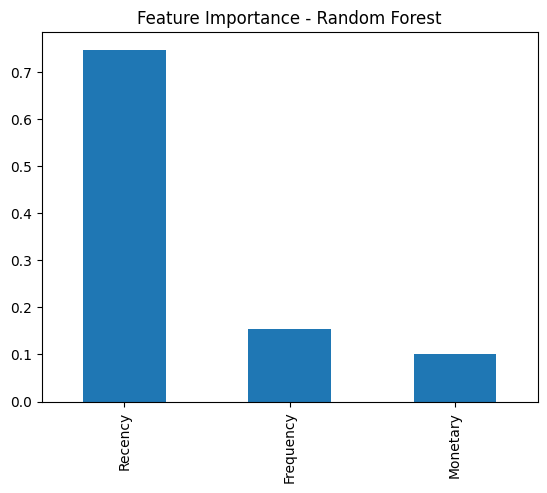

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

In [60]:
rfm_df["High_Value"] = rfm_df["Cluster"].apply(lambda x: 1 if x == 2 else 0)

rfm_df["High_Value"].value_counts()

,count
High_Value,
0,4325
1,13


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = rfm_df[["Recency", "Frequency", "Monetary"]]
y = rfm_df["High_Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_high = RandomForestClassifier(random_state=42)
rf_high.fit(X_train, y_train)

y_pred = rf_high.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       1.00      1.00      1.00         3

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



# saving models

In [62]:
import joblib

# Save scaler
joblib.dump(scaler, "rfm_scaler.pkl")

# Save KMeans model
joblib.dump(kmeans, "kmeans_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [63]:
joblib.dump(df_clean, "df_clean.pkl")

['df_clean.pkl']

In [64]:
rfm_df.to_csv("rfm_final.csv", index=False)

print("RFM dataset saved!")

RFM dataset saved!


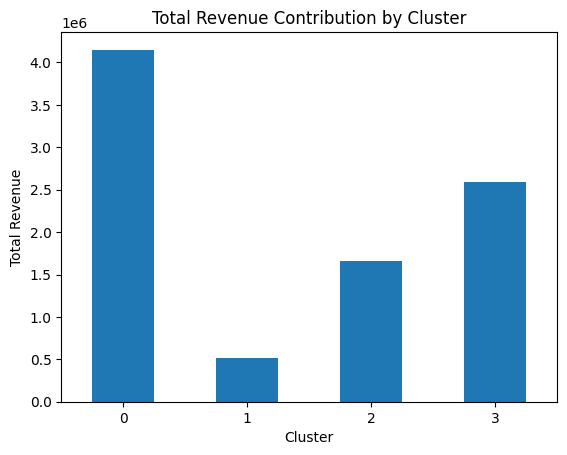

In [65]:
# Total revenue per cluster
revenue_by_cluster = rfm_df.groupby("Cluster")["Monetary"].sum().sort_index()

plt.figure()
revenue_by_cluster.plot(kind="bar")
plt.title("Total Revenue Contribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()